In [187]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import math
sys.path.append("../src/")

In [2]:
from integration import nodes_clenshaw_curtis, npts_clenshaw_curtis, weights_clenshaw_curtis

In [3]:
from interpolation import cheb8, cheb8_deriv, Cheb_coeffs_dct

/Users/alexlague/Documents/act/sfb/repo/polybessel/notebooks/../src/interpolation.py:214: SyntaxWarning: invalid escape sequence '\i'
  '''


In [4]:
from IN_integration import IN_Bessel_s2_single_func, IN_Bessel_s2_product_func, IN_Bessel_s2_hybrid_func

In [67]:
from scipy.special import jv
from scipy.integrate import quad
from numba import jit, vectorize

In [226]:
# to be moved to interpolation

@jit(nopython=True, inline='always')
def _jv_table_scalar(row, scale, imax, z):
    p = z * scale
    i = int(p)
    if i < 1:
        i = 1
    elif i > imax:
        i = imax
    t = p - i
    y0 = row[i-1]; y1 = row[i]; y2 = row[i+1]; y3 = row[i+2]
    return y1 + 0.5 * t * (y2 - y0 + t * (2.0*y0 - 5.0*y1 + 4.0*y2 - y3
                           + t * (3.0*(y1 - y2) + y3 - y0)))

@jit(nopython=True, inline='always')
def _jv_debye_scalar(nu, nu2, nu3, z):
    s = math.sqrt(z*z - nu2)
    c = nu / s
    c2 = c * c
    c4 = c2 * c2
    c6 = c4 * c2
    A = 1.0 - (81.0*c2 + 462.0*c4 + 385.0*c6) / 1152.0 / nu2
    B = (3.0*c + 5.0*c2*c) / 24.0 / nu \
        - c2*c * (30375.0 + 369603.0*c2 + 765765.0*c4 + 425425.0*c6) / 414720.0 / nu3
    xi = s - nu * math.acos(nu / z) - 0.25*math.pi
    return math.sqrt(2.0 / (math.pi * s)) * (A*math.cos(xi) + B*math.sin(xi))

@jit(nopython=True, fastmath=True)
def jv_interpolation(table, nu, x):
    """
    J_nu(x) for integer 1 <= nu <= table.shape[0]-1:
    tabulated (cubic) for x < 2*nu, Debye expansion for x >= 2*nu.
    """
    row = table[nu]
    scale = (row.shape[0] - 1) / (2.0 * nu)
    imax = row.shape[0] - 3
    nuf = float(nu)
    nu2 = nuf * nuf
    nu3 = nu2 * nuf
    xmax = 2.0 * nuf
    out = np.empty(x.shape[0])
    for j in range(x.shape[0]):
        z = x[j]
        if z < xmax:
            out[j] = _jv_table_scalar(row, scale, imax, z)
        else:
            out[j] = _jv_debye_scalar(nuf, nu2, nu3, z)
    return out

In [227]:
nu_max = 256
Jv_int_table = np.zeros((nu_max+1, 4096))
r = np.linspace(0.0, 2.0, 4096)
for nui in range(nu_max+1):
    xnu = r*nui
    Jv_int_table[nui, :] = jv(nui, xnu)

In [306]:
nu1 = 53
nu2 = 65
omega1 = 2.0
omega2 = 0.2
a = 2.*np.max((nu1/omega1, nu2/omega2))
b = 3*a
f = lambda x: x*np.exp(-x/1000)
fprime = lambda x: np.exp(-x/1000) -0.001*x*np.exp(-x/1000)

In [312]:
fa, fb, fpa, fpb = f(a), f(b), fprime(a), fprime(b)

In [313]:
# single integration

approx_ans = IN_Bessel_s2_single_func(nu1, omega1, a, b, fa, fb, fpa, fpb)
true_ans = quad(lambda x: f(x)*jv(nu1, omega1*x), a, b, limit=1000000, epsabs=1e-12)[0]
approx_ans/true_ans

0.9999998162588791

In [314]:
%timeit IN_Bessel_s2_single_func(nu1, omega1, a, b, fa, fb, fpa, fpb)

281 ns ± 2.91 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [230]:
# double integration with far separated omegas

approx_ans = IN_Bessel_s2_product_func(nu1, omega1, nu2, omega2, a, b, fa, fb, fpa, fpb)
true_ans = quad(lambda x: f(x)*jv(nu1, omega1*x)*jv(nu2, omega2*x), a, b, limit=1000000, epsabs=1e-12)[0]
approx_ans/true_ans

1.000000842391473

In [231]:
# double integration with close omegas

N = 1024
w = weights_clenshaw_curtis(N) * 0.5 * (b-a)
xcc = nodes_clenshaw_curtis(N, a, b)
fx = f(xcc)

approx_ans = IN_Bessel_s2_hybrid_func(nu1, omega1, nu2, omega2*9, a, b, fpa, fpb, xcc[::-1], fx[::-1], w[::-1])
true_ans = quad(lambda x: f(x)*jv(nu1, omega1*x)*jv(nu2, omega2*x*9), a, b, limit=1000000, epsabs=1e-12)[0]
approx_ans/true_ans

1.000000004649626

In [321]:
@jit(nopython=True)
def main_integration_Bessel_product(c, u, w, nu1, omega1, nu2, omega2, a, b, ncheb=2048):
    """
    Main wrapper to integrate any smooth function f (callable) with two Bessel functions
    f(x) * J_nu1(omega1*x) J_nu2(omega2*x)
    """
    
    # Get Cheb nodes on [-1, 1]
    #u = nodes_clenshaw_curtis(ncheb, -1, 1)
    
    # Get Cheb nodes on [a, b]
    xcc = 0.5*(b-a) * u + 0.5*(b+a)
    
    # Get Cheb weights
    #w = weights_clenshaw_curtis(ncheb) # for [-1, 1]
    
    # Cheb decomposition of deg 7 of f over the full interval
    #c = Cheb_coeffs_dct(f(xcc[::ncheb//8]))

    if (b*omega1/nu1 < 0.4 and nu1 >= 30) or (b*omega2/nu2 < 0.4 and nu2 >= 30):
        #print("Case 0")
        integral = 0.0
    
    elif a >= 2*max((nu1/omega1, nu2/omega2)):
        #print("Case A")
        fa, fb = cheb8(c, np.array([a, b]), a, b)
        fpa, fpb = cheb8_deriv(c, np.array([a, b]), a, b) # get from endpoints of Cheb expansion
        
        if np.abs(omega1-omega2) >= 0.5:
            #print("Case A1")
            integral = IN_Bessel_s2_product_func(nu1, omega1, nu2, omega2, a, b, fa, fb, fpa, fpb)
        else:
            #print("Case A2")
            fx = cheb8(c, xcc, a, b)
            rescaled_w = (0.5*(b-a)*w)
            integral = IN_Bessel_s2_hybrid_func(nu1, omega1, nu2, omega2, a, b, fpa, fpb, xcc[::-1], fx[::-1], rescaled_w[::-1])
    
    elif b <= 2*max((nu1/omega1, nu2/omega2)): # CC quadrature
        #print("Case B")
        f_at_nodes = cheb8(c, xcc, a, b)
        jv1 = jv_interpolation(Jv_int_table, nu1, omega1*xcc)
        jv2 = jv_interpolation(Jv_int_table, nu2, omega2*xcc)
        f_with_Bessel = f_at_nodes *jv1*jv2 #* jv(nu1, omega1*xcc)* jv(nu2, omega2*xcc)#
        rescaled_w = w*0.5*(b-a)
        integral = np.dot(rescaled_w, f_with_Bessel)
    
    else:
        a_tilde = 2*min((nu1/omega1, nu2/omega2))
        b_tilde = 2*max((nu1/omega1, nu2/omega2))
        
        # Piece 1/3: a to a tilde
        rescaled_nodes = 0.5*(a_tilde-a) * u + 0.5*(a_tilde+a)
        rescaled_w = w*0.5*(a_tilde-a)
        f_at_nodes = cheb8(c, rescaled_nodes, a, b)
        jv1 = jv_interpolation(Jv_int_table, nu1, omega1*rescaled_nodes)
        jv2 = jv_interpolation(Jv_int_table, nu2, omega2*rescaled_nodes)
        f_with_Bessel = f_at_nodes *jv1*jv2 #* jv(nu1, omega1*rescaled_nodes)*jv(nu2, omega2*rescaled_nodes)
        integral = np.dot(rescaled_w, f_with_Bessel)
    
        # Piece 2/3: a tilde to b tilde
        endp = np.array([a_tilde, b_tilde])
        fa_tilde, fb_tilde = cheb8(c, endp, a, b)
        fpa_tilde, fpb_tilde = cheb8_deriv(c, endp, a, b)
        if nu1/omega1 > nu2/omega2:
            jv_endp = jv_interpolation(Jv_int_table, nu2, omega2*endp)
            jv_endp_deriv = jv_interpolation(Jv_int_table, nu2-1, omega2*endp) #needs check if nu=0
            jv_endp_deriv -= nu1/endp * jv_endp
            
            fpa_tilde *= jv_endp[0]
            fpb_tilde *= jv_endp[1]
            fpa_tilde += fa_tilde * jv_endp_deriv[0] 
            fpb_tilde += fb_tilde * jv_endp_deriv[1] 
            
            integral += IN_Bessel_s2_single_func(nu1, omega1, a_tilde, b_tilde, fa_tilde, fb_tilde, fpa_tilde, fpb_tilde)
        else:
            jv_endp = jv_interpolation(Jv_int_table, nu1, omega1*endp)
            jv_endp_deriv = jv_interpolation(Jv_int_table, nu1-1, omega1*endp) #needs check if nu=0
            jv_endp_deriv -= nu1/endp * jv_endp
            
            fpa_tilde *= jv_endp[0]
            fpb_tilde *= jv_endp[1]
            fpa_tilde += fa_tilde * jv_endp_deriv[0] 
            fpb_tilde += fb_tilde * jv_endp_deriv[1]
            
            integral += IN_Bessel_s2_single_func(nu2, omega2, a_tilde, b_tilde, fa_tilde, fb_tilde, fpa_tilde, fpb_tilde)
        
        # Piece 3/3: b tilde to b
        fb_tilde, fb = cheb8(c, np.array([b_tilde, b]), a, b)
        fpb_tilde, fpb = cheb8_deriv(c, np.array([b_tilde, b]), a, b)
        if np.abs(omega1-omega2) >= 0.5:
            integral += IN_Bessel_s2_product_func(nu1, omega1, nu2, omega2, b_tilde, b, fb_tilde, fb, fpb_tilde, fpb)
        else:
            # Need to fix to hybrid
            integral += IN_Bessel_s2_product_func(nu1, omega1, nu2, omega2, b_tilde, b, fb_tilde, fb, fpb_tilde, fpb)
    
    return integral

In [324]:
ncheb = 2048
c = Cheb_coeffs_dct(f(nodes_clenshaw_curtis(8, a, b)))
u = nodes_clenshaw_curtis(ncheb, -1, 1)
w = weights_clenshaw_curtis(ncheb) # for [-1, 1]

In [343]:
nu1, nu2 = np.random.randint(0, 200, size=2)
omega1, omega2 = 10**np.random.uniform(-3, 1, size=2)
print(nu1, nu2, omega1, omega2, a, b)
approx_ans = main_integration_Bessel_product(c, u, w, nu1, omega1, nu2, omega2, a, b, ncheb=ncheb)
true_ans = quad(lambda x: f(x)*jv(nu1, omega1*x)*jv(nu2, omega2*x), a, b, limit=1000000, epsabs=1e-12)[0]
approx_ans/true_ans, np.abs(approx_ans-true_ans)

174 36 0.0028048861348920428 0.08426991780600811 650.0 1950.0


(-0.0, np.float64(2.2111652030719446e-238))

In [341]:
approx_ans, true_ans

(nan, 0.6320016722893456)

In [241]:
approx_ans = main_integration_Bessel_product(c,u, w, nu1, omega1, nu2, 9*omega2, a, b, ncheb=2048)
true_ans = quad(lambda x: f(x)*jv(nu1, omega1*x)*jv(nu2, 9*omega2*x), a, b, limit=1000000, epsabs=1e-12)[0]
approx_ans/true_ans

1.000000018235198

In [251]:
approx_ans = main_integration_Bessel_product(c, u, w, nu1, 10*omega1, nu2, omega2, a, b, ncheb=2048)
true_ans = quad(lambda x: f(x)*jv(nu1, 10*omega1*x)*jv(nu2, omega2*x), a, b, limit=1000000, epsabs=1e-30)[0]
approx_ans/true_ans

1.0000000300786092

In [344]:
%timeit main_integration_Bessel_product(c, u, w, nu1, omega1, nu2, omega2, a, b, ncheb=ncheb)

970 ns ± 13.7 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


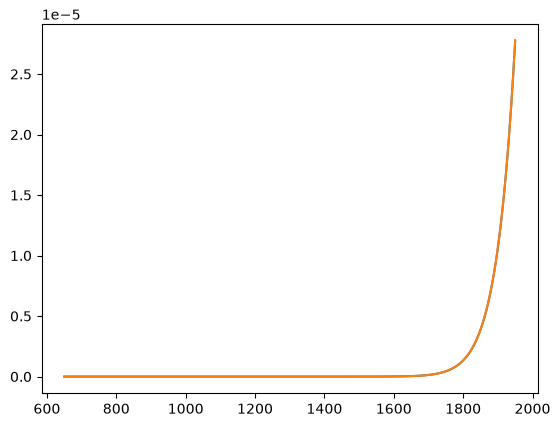

In [159]:
plt.plot(xcc, jv(53, omega2/10*xcc))
plt.plot(xcc, jv_interp_cubic(Jv_int_table, 53, omega2/10*xcc))

In [158]:
omega2/10*xcc.max()

np.float64(39.0)